In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
from currency_converter import CurrencyConverter
from datetime import date

## Read Data

In [4]:
# https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
li_small_accounts_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/LI-Small_accounts.csv')
li_small_accounts_df

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,China Bank #2820,314693,81B86A280,800D8CCF0,Corporation #41344
1,France Bank #4585,311253,8187FEA80,800B505E0,Corporation #54497
2,China Bank #2242,39996,803961E00,800D03F60,Partnership #36904
3,National Bank of Newport,331440,81B075800,801567C10,Corporation #16224
4,UK Bank #33,135417,80CF87C80,801085E00,Partnership #72930
...,...,...,...,...,...
712683,China Bank #42,692,80346A5F0,800D080A0,Corporation #40025
712684,First Bank of Watertown,118699,80B802A70,8005319C0,Partnership #14803
712685,Bank of Lincoln,213123,80847BE70,800453480,Partnership #11893
712686,Hilltop Credit Union,18747,803A36270,8003B5120,Partnership #6726


In [5]:
li_small_trans_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/LI-Small_trans.csv')
li_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3.195403e+06,US Dollar,3.195403e+06,US Dollar,Reinvestment,0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1.858960e+03,US Dollar,1.858960e+03,US Dollar,Reinvestment,0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,5.925710e+05,US Dollar,5.925710e+05,US Dollar,Cheque,0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,1.232000e+01,US Dollar,1.232000e+01,US Dollar,Reinvestment,0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2.941560e+03,US Dollar,2.941560e+03,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
6924044,2022/09/10 23:39,71696,81B2518F1,71528,81C0482E1,3.346900e-02,Bitcoin,3.346900e-02,Bitcoin,Bitcoin,0
6924045,2022/09/10 23:48,271241,81B567481,173457,81C0DA751,1.313000e-03,Bitcoin,1.313000e-03,Bitcoin,Bitcoin,0
6924046,2022/09/10 23:50,271241,81B567481,173457,81C0DA751,1.305800e-02,Bitcoin,1.305800e-02,Bitcoin,Bitcoin,0
6924047,2022/09/10 23:57,170558,81A2206B1,275798,81C1D5CA1,4.145370e-01,Bitcoin,4.145370e-01,Bitcoin,Bitcoin,0


In [6]:
hi_small_accounts_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/HI-Small_accounts.csv')
hi_small_accounts_df

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889
...,...,...,...,...,...
518576,France Bank #33,3881,807886B70,80062D160,Sole Proprietorship #22257
518577,National Bank of Topeka,333423,81314C870,800F40230,Sole Proprietorship #4995
518578,Plandor Trust Bank,1467,804ED2270,800CAC4C0,Sole Proprietorship #35326
518579,Sappo Bancorp,2843,801727270,800EFCB40,Sole Proprietorship #3522


In [14]:
hi_small_trans_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/HI-Small_trans.csv')
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0


## Summarize Data

In [8]:
li_small_accounts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712688 entries, 0 to 712687
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Bank Name       712688 non-null  object
 1   Bank ID         712688 non-null  int64 
 2   Account Number  712688 non-null  object
 3   Entity ID       712688 non-null  object
 4   Entity Name     712688 non-null  object
dtypes: int64(1), object(4)
memory usage: 27.2+ MB


In [9]:
li_small_trans_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924049 entries, 0 to 6924048
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Timestamp           6924049 non-null  object 
 1   From Bank           6924049 non-null  int64  
 2   Account             6924049 non-null  object 
 3   To Bank             6924049 non-null  int64  
 4   Account.1           6924049 non-null  object 
 5   Amount Received     6924049 non-null  float64
 6   Receiving Currency  6924049 non-null  object 
 7   Amount Paid         6924049 non-null  float64
 8   Payment Currency    6924049 non-null  object 
 9   Payment Format      6924049 non-null  object 
 10  Is Laundering       6924049 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 581.1+ MB


In [10]:
hi_small_accounts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Bank Name       518581 non-null  object
 1   Bank ID         518581 non-null  int64 
 2   Account Number  518581 non-null  object
 3   Entity ID       518581 non-null  object
 4   Entity Name     518581 non-null  object
dtypes: int64(1), object(4)
memory usage: 19.8+ MB


In [19]:
hi_small_trans_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Timestamp           5078345 non-null  object 
 1   From Bank           5078345 non-null  int64  
 2   Account             5078345 non-null  object 
 3   To Bank             5078345 non-null  int64  
 4   Account.1           5078345 non-null  object 
 5   Amount Received     5078345 non-null  float64
 6   Receiving Currency  5078345 non-null  object 
 7   Amount Paid         5078345 non-null  float64
 8   Payment Currency    5078345 non-null  object 
 9   Payment Format      5078345 non-null  object 
 10  Is Laundering       5078345 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


There are no null values in any of the datasets

The account dataframes show details about accounts, what bank the account belongs to, and the business entity that owns the bank account

The transactions show different types of payments between accounts

The reasoning for the datasets being split into two groups is as follows:

- Group HI has a relatively higher illicit ratio (more laundering).
- Group LI has a relatively lower illicit ratio (less laundering).

In [ ]:
len(hi_small_accounts_df['Account Number'].unique())

518573

In [ ]:
hi_small_trans_df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06
mean,4.573057e+04,6.574456e+04,5.988726e+06,4.509273e+06,1.019427e-03
std,8.176562e+04,8.409299e+04,1.037183e+09,8.697728e+08,3.191219e-02
min,1.000000e+00,1.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,1.190000e+02,4.259000e+03,1.833700e+02,1.844800e+02,0.000000e+00
50%,9.679000e+03,2.156800e+04,1.411010e+03,1.414540e+03,0.000000e+00
75%,2.862800e+04,1.223320e+05,1.234627e+04,1.229784e+04,0.000000e+00
max,3.563030e+05,3.562940e+05,1.046302e+12,1.046302e+12,1.000000e+00


In [ ]:
li_small_trans_df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06
mean,5.938718e+04,8.441702e+04,6.324067e+06,4.676036e+06,5.148722e-04
std,9.051700e+04,9.064562e+04,2.105371e+09,1.544099e+09,2.268495e-02
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,2.190000e+02,1.125500e+04,1.742100e+02,1.753800e+02,0.000000e+00
50%,1.419500e+04,2.964000e+04,1.397620e+03,1.399440e+03,0.000000e+00
75%,1.106820e+05,1.480400e+05,1.229633e+04,1.222687e+04,0.000000e+00
max,3.769670e+05,3.769670e+05,3.644854e+12,3.644854e+12,1.000000e+00


In [ ]:
li_small_trans_df.sort_values(by="Amount Paid").tail(5)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
510834,2022/09/01 01:46,123800,808B7F870,119699,809CE4D70,3.871530e+11,Rupee,3.871530e+11,Rupee,Cash,0
1334434,2022/09/01 19:57,215278,8068972A0,123135,8145F9B50,6.653123e+11,Yen,6.653123e+11,Yen,Cheque,0
6883964,2022/09/10 20:14,25552,80ABDDA10,23494,80ABDF080,6.779867e+11,Rupee,6.779867e+11,Rupee,ACH,0
3007683,2022/09/04 13:44,123260,80A274810,2,80A286620,8.623400e+11,Rupee,8.623400e+11,Rupee,ACH,0
2525880,2022/09/02 23:06,11047,8018B08B0,22297,8157483D0,3.644854e+12,Yen,3.644854e+12,Yen,Cheque,0


In [ ]:
li_small_trans_df['Payment Currency'].unique()

array(['US Dollar', 'Euro', 'Bitcoin', 'Yuan', 'Yen', 'UK Pound',
       'Brazil Real', 'Australian Dollar', 'Rupee', 'Ruble',
       'Canadian Dollar', 'Mexican Peso', 'Swiss Franc', 'Shekel',
       'Saudi Riyal'], dtype=object)

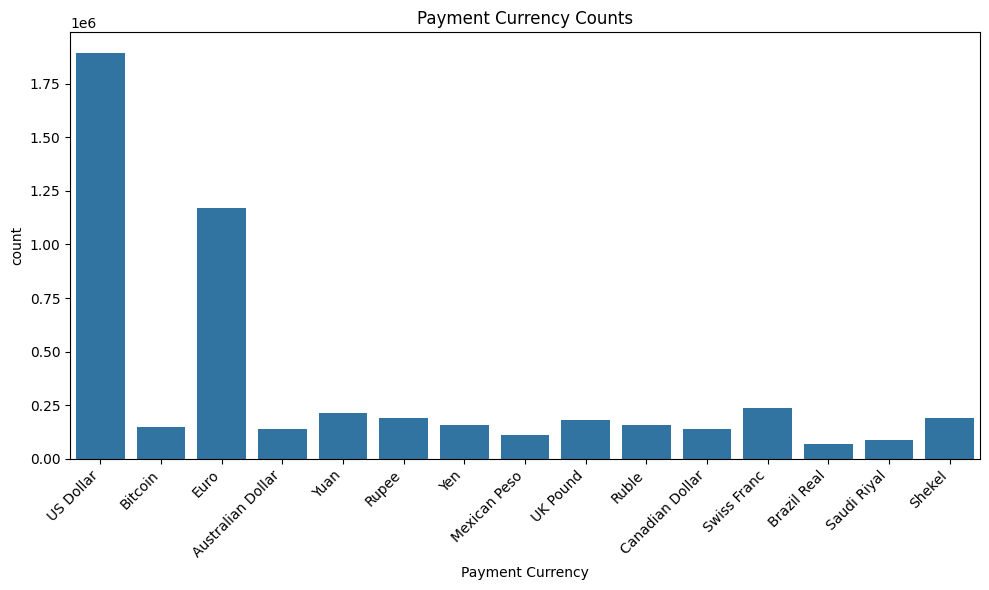

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x='Payment Currency', data=hi_small_trans_df, ax=ax)
plt.xticks(rotation=45, ha='right') 
ax.set_title("Payment Currency Counts")
plt.tight_layout()
plt.savefig("ibm_figs/payment_currency_counts.png")

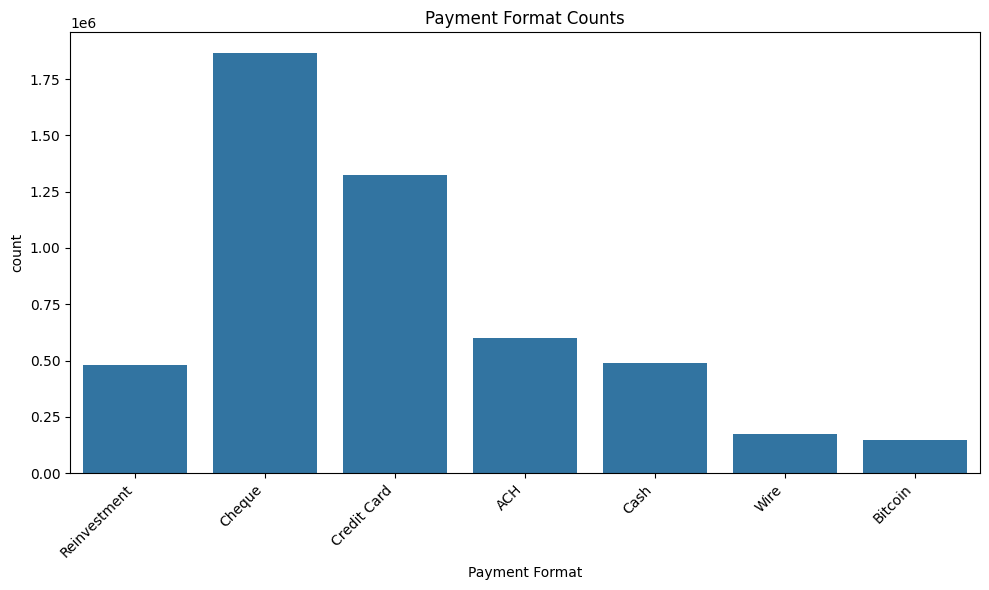

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x='Payment Format', data=hi_small_trans_df, ax=ax)
plt.xticks(rotation=45, ha='right') 
ax.set_title("Payment Format Counts")
plt.tight_layout()
plt.savefig("ibm_figs/payment_format_counts.png")

## Preprocess the Amounts for Currency Conversion

In [ ]:
li_small_trans_df[li_small_trans_df['Receiving Currency'] != li_small_trans_df['Payment Currency']]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
2770,2022/09/01 00:12,394,80056EDE0,394,80056EDE0,47.610000,Euro,55.79,US Dollar,ACH,0
8081,2022/09/01 00:28,11701,800C95BF0,11701,800C95BF0,954.620000,Yuan,142.53,US Dollar,ACH,0
10451,2022/09/01 00:18,22481,80105E630,22481,80105E630,16930.030000,Yen,160.63,US Dollar,ACH,0
12948,2022/09/01 00:17,1439,8014545C0,1439,8014545C0,14.520000,UK Pound,18.76,US Dollar,ACH,0
13799,2022/09/01 00:02,20,8015D68E0,20,8015D68E0,37.000000,Euro,43.35,US Dollar,ACH,0
...,...,...,...,...,...,...,...,...,...,...,...
6924007,2022/09/10 23:57,9096,80356BD61,9096,80356BD60,0.000005,Bitcoin,0.39,Yuan,ACH,0
6924009,2022/09/10 23:30,9096,80356BD61,9096,80356BD60,0.000007,Bitcoin,0.55,Yuan,ACH,0
6924019,2022/09/10 23:38,13474,803A93631,13474,803A93630,0.000007,Bitcoin,0.08,US Dollar,ACH,0
6924021,2022/09/10 23:31,13474,803A93631,13474,803A93630,0.000020,Bitcoin,0.23,US Dollar,ACH,0


We want to maintain the Payment/Receiving Currency, since it indicates if a transaction was sent/received in the same country. We should scale all the currencys to a single currency like Dollar to make them comparable.

In [20]:
# 1 of XYZ currency to USD as of 9/1/2022 via https://www.exchangerates.org.uk/historical/.../01_09_2022
usd_to_usd = 1
euro_to_usd = 0.9945
btc_to_usd = 20050.50 # Opening BTC price
yuan_to_usd =  0.1446
yen_to_usd = 0.0071
pound_to_usd = 1.154
brazil_to_usd = 0.1907
aus_to_usd = 0.6789
rupee_to_usd =  0.0125 # Assuming Indian Rupee
ruble_to_usd = 0.0166
canadian_to_usd = 0.7601
peso_to_usd = 0.0495
swiss_to_usd = 1.0184
shekel_to_usd = 0.2943
riyal_to_usd = 0.266

In [21]:
currency_map = {
    'US Dollar': usd_to_usd,
    'Euro': euro_to_usd, 
    'Bitcoin': btc_to_usd, 
    'Yuan': yuan_to_usd, 
    'Yen': yen_to_usd, 
    'UK Pound': pound_to_usd,
    'Brazil Real': brazil_to_usd,
    'Australian Dollar': aus_to_usd, 
    'Rupee': rupee_to_usd, 
    'Ruble': ruble_to_usd,
    'Canadian Dollar': canadian_to_usd, 
    'Mexican Peso': peso_to_usd, 
    'Swiss Franc': swiss_to_usd, 
    'Shekel': shekel_to_usd,
    'Saudi Riyal': riyal_to_usd,
}

In [ ]:
li_small_trans_df['Amount_Received_USD'] = li_small_trans_df.apply(lambda row: row['Amount Received'] * currency_map[row['Receiving Currency']], axis=1)
li_small_trans_df['Amount_Paid_USD'] = li_small_trans_df.apply(lambda row: row['Amount Paid'] * currency_map[row['Payment Currency']], axis=1)

NameError: name 'li_small_trans_df' is not defined

In [ ]:
li_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3.195403e+06,US Dollar,3.195403e+06,US Dollar,Reinvestment,0,3.195403e+06,3.195403e+06
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1.858960e+03,US Dollar,1.858960e+03,US Dollar,Reinvestment,0,1.858960e+03,1.858960e+03
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,5.925710e+05,US Dollar,5.925710e+05,US Dollar,Cheque,0,5.925710e+05,5.925710e+05
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,1.232000e+01,US Dollar,1.232000e+01,US Dollar,Reinvestment,0,1.232000e+01,1.232000e+01
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2.941560e+03,US Dollar,2.941560e+03,US Dollar,Reinvestment,0,2.941560e+03,2.941560e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6924044,2022/09/10 23:39,71696,81B2518F1,71528,81C0482E1,3.346900e-02,Bitcoin,3.346900e-02,Bitcoin,Bitcoin,0,6.710702e+02,6.710702e+02
6924045,2022/09/10 23:48,271241,81B567481,173457,81C0DA751,1.313000e-03,Bitcoin,1.313000e-03,Bitcoin,Bitcoin,0,2.632631e+01,2.632631e+01
6924046,2022/09/10 23:50,271241,81B567481,173457,81C0DA751,1.305800e-02,Bitcoin,1.305800e-02,Bitcoin,Bitcoin,0,2.618194e+02,2.618194e+02
6924047,2022/09/10 23:57,170558,81A2206B1,275798,81C1D5CA1,4.145370e-01,Bitcoin,4.145370e-01,Bitcoin,Bitcoin,0,8.311674e+03,8.311674e+03


In [22]:
hi_small_trans_df['Amount_Received_USD'] = hi_small_trans_df.apply(lambda row: row['Amount Received'] * currency_map[row['Receiving Currency']], axis=1)
hi_small_trans_df['Amount_Paid_USD'] = hi_small_trans_df.apply(lambda row: row['Amount Paid'] * currency_map[row['Payment Currency']], axis=1)

In [ ]:
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0,3697.340000,3697.340000
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0,0.010000,0.010000
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0,14675.570000,14675.570000
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0,2806.970000,2806.970000
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0,36682.970000,36682.970000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0,3107.386389,3107.386389
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0,2168.020464,2168.020464
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0,100.011894,100.011894
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0,770.280058,770.280058


In [ ]:
# hi_small_trans_df = hi_small_trans_df.drop(columns=['Amount Paid', 'Amount Received'])
# hi_small_trans_df

In [ ]:
# li_small_trans_df = li_small_trans_df.drop(columns=['Amount Paid', 'Amount Received'])
# li_small_trans_df

In [ ]:
li_small_trans_df['Amount_Paid_USD'].min(), li_small_trans_df['Amount_Paid_USD'].max() 

(np.float64(7.1e-05), np.float64(34581154295.51))

In [ ]:
li_small_trans_df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD
count,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06
mean,5.938718e+04,8.441702e+04,6.324067e+06,4.676036e+06,5.148722e-04,3.433776e+05,3.455678e+05
std,9.051700e+04,9.064562e+04,2.105371e+09,1.544099e+09,2.268495e-02,2.431300e+07,2.586574e+07
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00,7.100000e-05,7.100000e-05
25%,2.190000e+02,1.125500e+04,1.742100e+02,1.753800e+02,0.000000e+00,1.520744e+02,1.520889e+02
50%,1.419500e+04,2.964000e+04,1.397620e+03,1.399440e+03,0.000000e+00,8.599908e+02,8.597651e+02
75%,1.106820e+05,1.480400e+05,1.229633e+04,1.222687e+04,0.000000e+00,5.084240e+03,5.084630e+03
max,3.769670e+05,3.769670e+05,3.644854e+12,3.644854e+12,1.000000e+00,2.587846e+10,3.458115e+10


## Engineer Mean/Median Amount per Currency

In [ ]:
# Need this for later
unique_currencies = hi_small_trans_df['Payment Currency'].unique()

In [ ]:
results = {}
for currency in unique_currencies:
    # Get subset of df with that currency
    subset_df = hi_small_trans_df[hi_small_trans_df['Payment Currency'] == currency]
    amount_paid_mean = subset_df['Amount Paid'].mean()
    amount_paid_median = subset_df['Amount Paid'].median()
    received_paid_mean = subset_df['Amount Received'].mean()
    received_paid_median = subset_df['Amount Received'].median()
    results[currency] = {
        f'{currency}_Amount_Paid_Mean': amount_paid_mean,
        f'{currency}_Amount_Paid_Median': amount_paid_median,
        f'{currency}_Amount_Received_Mean': received_paid_mean,
        f'{currency}_Amount_Received_Median': received_paid_median,
    }
results

{'US Dollar': {'US Dollar_Amount_Paid_Mean': np.float64(367153.78054103284),
  'US Dollar_Amount_Paid_Median': np.float64(904.13),
  'US Dollar_Amount_Received_Mean': np.float64(4041978.6200048206),
  'US Dollar_Amount_Received_Median': np.float64(908.2)},
 'Bitcoin': {'Bitcoin_Amount_Paid_Mean': np.float64(20.80927476327825),
  'Bitcoin_Amount_Paid_Median': np.float64(0.069869),
  'Bitcoin_Amount_Received_Mean': np.float64(25.399915298125507),
  'Bitcoin_Amount_Received_Median': np.float64(0.070055)},
 'Euro': {'Euro_Amount_Paid_Mean': np.float64(263134.47403084155),
  'Euro_Amount_Paid_Median': np.float64(747.31),
  'Euro_Amount_Received_Mean': np.float64(691414.5679962023),
  'Euro_Amount_Received_Median': np.float64(750.58)},
 'Australian Dollar': {'Australian Dollar_Amount_Paid_Mean': np.float64(342938.7727294197),
  'Australian Dollar_Amount_Paid_Median': np.float64(1301.55),
  'Australian Dollar_Amount_Received_Mean': np.float64(343694.4472716691),
  'Australian Dollar_Amount_Re

In [ ]:
for k,v in results.items():
    for stat, val in v.items():
        hi_small_trans_df[stat] = val
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,...,Brazil Real_Amount_Received_Mean,Brazil Real_Amount_Received_Median,Saudi Riyal_Amount_Paid_Mean,Saudi Riyal_Amount_Paid_Median,Saudi Riyal_Amount_Received_Mean,Saudi Riyal_Amount_Received_Median,Shekel_Amount_Paid_Mean,Shekel_Amount_Paid_Median,Shekel_Amount_Received_Mean,Shekel_Amount_Received_Median
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675


## Preprocess the Categorical Features

In [ ]:
li_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3.195403e+06,US Dollar,3.195403e+06,US Dollar,Reinvestment,0,3.195403e+06,3.195403e+06
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1.858960e+03,US Dollar,1.858960e+03,US Dollar,Reinvestment,0,1.858960e+03,1.858960e+03
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,5.925710e+05,US Dollar,5.925710e+05,US Dollar,Cheque,0,5.925710e+05,5.925710e+05
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,1.232000e+01,US Dollar,1.232000e+01,US Dollar,Reinvestment,0,1.232000e+01,1.232000e+01
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2.941560e+03,US Dollar,2.941560e+03,US Dollar,Reinvestment,0,2.941560e+03,2.941560e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6924044,2022/09/10 23:39,71696,81B2518F1,71528,81C0482E1,3.346900e-02,Bitcoin,3.346900e-02,Bitcoin,Bitcoin,0,6.710702e+02,6.710702e+02
6924045,2022/09/10 23:48,271241,81B567481,173457,81C0DA751,1.313000e-03,Bitcoin,1.313000e-03,Bitcoin,Bitcoin,0,2.632631e+01,2.632631e+01
6924046,2022/09/10 23:50,271241,81B567481,173457,81C0DA751,1.305800e-02,Bitcoin,1.305800e-02,Bitcoin,Bitcoin,0,2.618194e+02,2.618194e+02
6924047,2022/09/10 23:57,170558,81A2206B1,275798,81C1D5CA1,4.145370e-01,Bitcoin,4.145370e-01,Bitcoin,Bitcoin,0,8.311674e+03,8.311674e+03


In [ ]:
len(li_small_trans_df['Payment Currency'].unique())

15

In [ ]:
len(li_small_trans_df['Payment Format'].unique())

7

In [ ]:
# I need to convert the Receiving Currency, Payment Currency, Payment Format into numeric encodings. I will use One Hot encoding since there is no order and not too many unique values

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'Receiving Currency',
    'Payment Currency',
    'Payment Format',
]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = encoder.fit_transform(li_small_trans_df[categorical_features])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_features))
li_small_trans_cleaned_df = pd.concat([li_small_trans_df.drop(categorical_features, axis=1), one_hot_df], axis=1)
li_small_trans_cleaned_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,...,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3.195403e+06,3.195403e+06,0,3.195403e+06,3.195403e+06,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1.858960e+03,1.858960e+03,0,1.858960e+03,1.858960e+03,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,5.925710e+05,5.925710e+05,0,5.925710e+05,5.925710e+05,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,1.232000e+01,1.232000e+01,0,1.232000e+01,1.232000e+01,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2.941560e+03,2.941560e+03,0,2.941560e+03,2.941560e+03,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6924044,2022/09/10 23:39,71696,81B2518F1,71528,81C0482E1,3.346900e-02,3.346900e-02,0,6.710702e+02,6.710702e+02,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6924045,2022/09/10 23:48,271241,81B567481,173457,81C0DA751,1.313000e-03,1.313000e-03,0,2.632631e+01,2.632631e+01,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6924046,2022/09/10 23:50,271241,81B567481,173457,81C0DA751,1.305800e-02,1.305800e-02,0,2.618194e+02,2.618194e+02,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6924047,2022/09/10 23:57,170558,81A2206B1,275798,81C1D5CA1,4.145370e-01,4.145370e-01,0,8.311674e+03,8.311674e+03,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
one_hot_encoded = encoder.transform(hi_small_trans_df[categorical_features])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_features))
hi_small_trans_cleaned_df = pd.concat([hi_small_trans_df.drop(categorical_features, axis=1), one_hot_df], axis=1)
hi_small_trans_cleaned_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,...,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,3697.340000,0,3697.340000,3697.340000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,0.010000,0,0.010000,0.010000,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,14675.570000,0,14675.570000,14675.570000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,2806.970000,0,2806.970000,2806.970000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,36682.970000,0,36682.970000,36682.970000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,0.154978,0,3107.386389,3107.386389,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,0.108128,0,2168.020464,2168.020464,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,0.004988,0,100.011894,100.011894,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,0.038417,0,770.280058,770.280058,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
hi_small_trans_cleaned_df.columns

Index(['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
       'Amount Received', 'Amount Paid', 'Is Laundering',
       'Amount_Received_USD', 'Amount_Paid_USD',
       ...
       'Payment Currency_US Dollar', 'Payment Currency_Yen',
       'Payment Currency_Yuan', 'Payment Format_ACH', 'Payment Format_Bitcoin',
       'Payment Format_Cash', 'Payment Format_Cheque',
       'Payment Format_Credit Card', 'Payment Format_Reinvestment',
       'Payment Format_Wire'],
      dtype='object', length=107)

In [ ]:
hi_small_trans_cleaned_df.to_csv('C:/Users/caleb/Downloads/ibm_aml/HI-Small_trans_cleaned.csv')

## Engineer Account and Bank sent/received is same

In [ ]:
hi_small_trans_cleaned_df['Account_Same'] = (hi_small_trans_cleaned_df['Account'] == hi_small_trans_cleaned_df['Account.1']).astype(int)

In [ ]:
hi_small_trans_cleaned_df['Bank_Same'] = (hi_small_trans_cleaned_df['From Bank'] == hi_small_trans_cleaned_df['To Bank']).astype(int)

In [ ]:
hi_small_trans_cleaned_df[['Account_Same', 'Bank_Same']]

,Account_Same,Bank_Same
0,1,1
1,0,0
2,1,1
3,1,1
4,1,1
...,...,...
5078340,0,0
5078341,0,0
5078342,0,0
5078343,0,1


## Export Data

In [ ]:
hi_small_trans_cleaned_df.to_csv('ibm_hi_small_trans_cleaned.csv', index=False)

## Check for Inifinite Values and Duplicates

In [ ]:
hi_small_accounts_num_df = hi_small_accounts_df.select_dtypes(include=[np.number])

# Find rows where ANY column has an infinite value
rows_with_inf = hi_small_accounts_df[np.isinf(hi_small_accounts_num_df).any(axis=1)]
rows_with_inf

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [ ]:
li_small_accounts_num_df = li_small_accounts_df.select_dtypes(include=[np.number])
# Find rows where ANY column has an infinite value
rows_with_inf = li_small_accounts_df[np.isinf(li_small_accounts_num_df).any(axis=1)]
rows_with_inf

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [ ]:
hi_small_trans_num_df = hi_small_trans_df.select_dtypes(include=[np.number])

# Find rows where ANY column has an infinite value
rows_with_inf = hi_small_trans_df[np.isinf(hi_small_trans_num_df).any(axis=1)]
rows_with_inf

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,...,Brazil Real_Amount_Received_Mean,Brazil Real_Amount_Received_Median,Saudi Riyal_Amount_Paid_Mean,Saudi Riyal_Amount_Paid_Median,Saudi Riyal_Amount_Received_Mean,Saudi Riyal_Amount_Received_Median,Shekel_Amount_Paid_Mean,Shekel_Amount_Paid_Median,Shekel_Amount_Received_Mean,Shekel_Amount_Received_Median


In [ ]:
li_small_trans_num_df = li_small_trans_df.select_dtypes(include=[np.number])

# Find rows where ANY column has an infinite value
rows_with_inf = li_small_trans_df[np.isinf(li_small_trans_num_df).any(axis=1)]
rows_with_inf

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD


There are no inf values

In [ ]:
hi_small_accounts_df[hi_small_accounts_df.duplicated(keep=False)]

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [ ]:
li_small_accounts_df[li_small_accounts_df.duplicated(keep=False)]

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [ ]:
hi_small_trans_df[hi_small_trans_df.duplicated(keep=False)]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,...,Brazil Real_Amount_Received_Mean,Brazil Real_Amount_Received_Median,Saudi Riyal_Amount_Paid_Mean,Saudi Riyal_Amount_Paid_Median,Saudi Riyal_Amount_Received_Mean,Saudi Riyal_Amount_Received_Median,Shekel_Amount_Paid_Mean,Shekel_Amount_Paid_Median,Shekel_Amount_Received_Mean,Shekel_Amount_Received_Median
863293,2022/09/01 16:20,12004,800C927C1,12004,800C927C0,0.000008,Bitcoin,0.080000,Euro,ACH,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
863294,2022/09/01 16:20,12004,800C927C1,220,813D8C1E1,0.000008,Bitcoin,0.000008,Bitcoin,Bitcoin,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
863295,2022/09/01 16:20,12004,800C927C1,12004,800C927C0,0.000008,Bitcoin,0.080000,Euro,ACH,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
863296,2022/09/01 16:20,12004,800C927C1,220,813D8C1E1,0.000008,Bitcoin,0.000008,Bitcoin,Bitcoin,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
3684003,2022/09/07 21:25,29992,8099A29B1,220,813725AE1,0.000003,Bitcoin,0.000003,Bitcoin,Bitcoin,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
3684005,2022/09/07 21:25,29992,8099A29B1,220,813725AE1,0.000003,Bitcoin,0.000003,Bitcoin,Bitcoin,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
4166784,2022/09/08 21:05,113779,811144AB1,113779,811144AB0,0.000002,Bitcoin,0.020000,US Dollar,ACH,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
4166785,2022/09/08 21:05,113779,811144AB1,53744,813C777F1,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
4166786,2022/09/08 21:05,113779,811144AB1,113779,811144AB0,0.000002,Bitcoin,0.020000,US Dollar,ACH,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675
4166787,2022/09/08 21:05,113779,811144AB1,53744,813C777F1,0.000002,Bitcoin,0.000002,Bitcoin,Bitcoin,...,4.383607e+06,5313.43,715956.332159,3488.82,715601.658704,3488.15,985408.894493,3115.04,985411.504035,3113.675


In [ ]:
li_small_trans_df[li_small_trans_df.duplicated(keep=False)]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
676694,2022/09/01 05:03,21260,8085A09D1,72146,81AB967E1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,0.020050,0.020050
676696,2022/09/01 05:03,21260,8085A09D1,72146,81AB967E1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,0.020050,0.020050
790828,2022/09/01 07:44,231616,814E45511,171546,81B324AC1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,0.020050,0.020050
790830,2022/09/01 07:44,231616,814E45511,171546,81B324AC1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,0.020050,0.020050
2027614,2022/09/02 11:09,28335,804B468F1,171669,81BBCDAB1,0.000007,Bitcoin,0.000007,Bitcoin,Bitcoin,0,0.140353,0.140353
2027616,2022/09/02 11:09,28335,804B468F1,171669,81BBCDAB1,0.000007,Bitcoin,0.000007,Bitcoin,Bitcoin,0,0.140353,0.140353
3482551,2022/09/05 12:44,22661,80D016C81,269294,81A245E81,0.000005,Bitcoin,0.000005,Bitcoin,Bitcoin,0,0.100253,0.100253
3482553,2022/09/05 12:44,22661,80D016C81,269294,81A245E81,0.000005,Bitcoin,0.000005,Bitcoin,Bitcoin,0,0.100253,0.100253
4180129,2022/09/06 14:16,19970,804E44F11,169489,8197DC971,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,0.020050,0.020050
4180131,2022/09/06 14:16,19970,804E44F11,169489,8197DC971,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,0,0.020050,0.020050


The identified duplicates are duplicate transactions. Since this just means the same amount is sent between the same accounts, I will leave these as valid samples.

## Boxplots

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(hi_small_trans_df, ax=ax)
ax.set_title("Boxplots")
plt.savefig("ibm_figs/boxplots.png")

<Axes: >

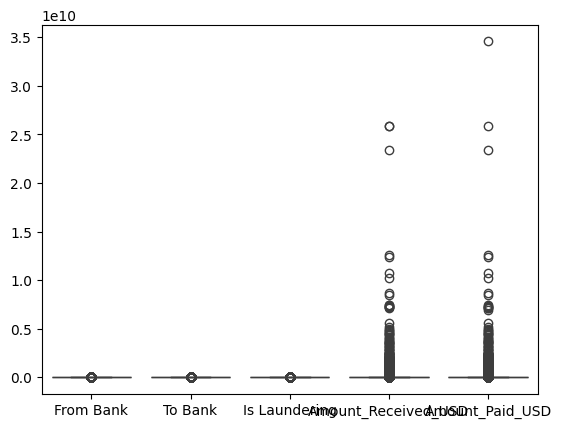

In [ ]:
sns.boxplot(li_small_trans_df)

## Univariate Analysis

<Axes: ylabel='Count'>

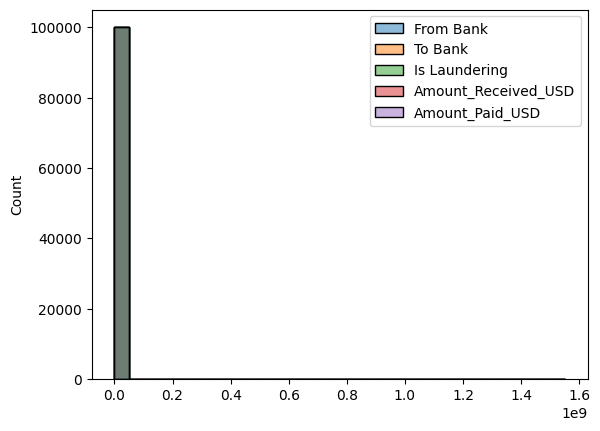

In [ ]:
sns.histplot(hi_small_trans_df.sample(100_000), bins=30)

## Correlations

In [ ]:
def get_highest_correlations(df, n_pairs=10):
    # 1. Compute the correlation matrix
    corr_matrix = df.corr(numeric_only=True)
    
    # 2. Unstack the correlation matrix to a Series and sort it
    # sort_values() sorts by correlation value, here we use absolute for highest impact (positive or negative)
    corr_series = corr_matrix.unstack().sort_values(ascending=False)
    
    # 3. Remove self-correlations (where feature A correlates with feature A, value is 1.0)
    # The redundant pairs (A,B) and (B,A) are still present at this stage
    corr_series = corr_series[corr_series < 1.0]

    # 4. Filter for unique pairs only (e.g., keep (A,B) and remove (B,A))
    # This involves iterating and checking if the reverse pair has already been added
    unique_pairs = {}
    for index, value in corr_series.items():
        pair = tuple(sorted(index))
        # Add to dictionary if not already present (sorting guarantees the same tuple for A,B and B,A)
        if pair not in unique_pairs:
            # Store with the original index structure to preserve order
            unique_pairs[pair] = value
    
    # Convert back to a Series for easy sorting and display
    unique_corr_series = pd.Series(unique_pairs).sort_values(ascending=False)

    # 5. Return the top N pairs
    return unique_corr_series.head(n_pairs)

# Get the top 5 highest correlations
top_correlations = get_highest_correlations(hi_small_trans_cleaned_df, n_pairs=5)
top_correlations

Payment Currency_Bitcoin      Payment Format_Bitcoin            0.999538
Amount_Paid_USD               Amount_Received_USD               0.997593
Payment Currency_Saudi Riyal  Receiving Currency_Saudi Riyal    0.993173
Payment Currency_Bitcoin      Receiving Currency_Bitcoin        0.992357
Payment Format_Bitcoin        Receiving Currency_Bitcoin        0.992270
dtype: float64

In [ ]:
hi_small_trans_cleaned_df.corr(numeric_only=True)

,From Bank,To Bank,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,...,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
From Bank,1.000000,0.289931,-0.000230,-0.001001,-0.000992,0.030758,0.068863,0.049745,0.016290,-0.106526,...,-0.052985,0.041262,0.068848,-0.041594,-0.061504,-0.037458,0.126014,-0.018565,0.114353,0.097062
To Bank,0.289931,1.000000,-0.005723,-0.001009,-0.000980,0.004407,0.098264,0.053725,0.010414,-0.105857,...,-0.063201,-0.024729,0.099105,-0.011310,-0.021884,-0.016035,0.045539,-0.005447,0.024798,-0.000103
Is Laundering,-0.000230,-0.005723,1.000000,0.006140,0.006244,-0.000538,-0.003484,-0.000834,-0.000604,0.002595,...,-0.001042,0.073949,-0.003431,-0.008195,-0.020182,-0.016068,-0.010333,-0.005979,-0.011384,-0.010828
Amount_Received_USD,-0.001001,-0.001009,0.006140,1.000000,0.997593,-0.000765,0.000458,0.002653,0.000709,-0.001959,...,-0.000913,0.008072,0.000495,0.001895,0.001457,-0.008159,-0.001315,0.000081,0.001579,0.001380
Amount_Paid_USD,-0.000992,-0.000980,0.006244,0.997593,1.000000,-0.000764,0.000480,0.002681,0.000727,-0.001932,...,-0.000907,0.007978,0.000517,0.001954,0.001544,-0.008245,-0.001310,0.000098,0.001377,0.001193
Receiving Currency_Australian Dollar,0.030758,0.004407,-0.000538,-0.000765,-0.000764,1.000000,-0.029027,-0.020017,-0.028334,-0.091721,...,-0.034228,0.001046,-0.028819,0.001027,0.004835,0.004378,-0.001341,0.001750,-0.000898,0.006399
Receiving Currency_Bitcoin,0.068863,0.098264,-0.003484,0.000458,0.000480,-0.029027,1.000000,-0.020722,-0.029332,-0.094952,...,-0.035521,-0.057814,0.992270,-0.056706,-0.132026,-0.102908,-0.056075,-0.028761,0.033088,0.045273
Receiving Currency_Brazil Real,0.049745,0.053725,-0.000834,0.002653,0.002681,-0.020017,-0.020722,1.000000,-0.020227,-0.065477,...,-0.024583,0.002354,-0.020573,0.001591,0.003443,0.000944,-0.000349,0.001311,0.001594,0.011126
Receiving Currency_Canadian Dollar,0.016290,0.010414,-0.000604,0.000709,0.000727,-0.028334,-0.029332,-0.020227,1.000000,-0.092685,...,-0.034176,0.005240,-0.029122,0.001126,0.003315,0.003043,-0.000492,0.000294,-0.000002,0.010600
Receiving Currency_Euro,-0.106526,-0.105857,0.002595,-0.001959,-0.001932,-0.091721,-0.094952,-0.065477,-0.092685,1.000000,...,-0.111956,0.008796,-0.094166,0.001129,0.010581,0.010810,0.008996,0.000476,-0.001080,-0.018280


In [ ]:
sorted(hi_small_trans_cleaned_df.corr(numeric_only=True)['Is Laundering'])

[-0.020182059084292304,
 -0.016068024647147596,
 -0.011383791956015974,
 -0.010827810194980315,
 -0.010333474576810223,
 -0.008194535919399655,
 -0.005978539285132068,
 -0.0057234370870873205,
 -0.003484301131569657,
 -0.003430524744683222,
 -0.003429868719067159,
 -0.003332552921647034,
 -0.0032633781738005815,
 -0.0017553645348836115,
 -0.0017402266754377317,
 -0.0014456695215322992,
 -0.0013639197448358951,
 -0.0010418907427313993,
 -0.0009763478614948191,
 -0.0009314615826473533,
 -0.0009031893593821269,
 -0.0008939858172314723,
 -0.0008741128616307157,
 -0.0008598239789472171,
 -0.0008342527327390402,
 -0.0008297973964018609,
 -0.0007939790167642299,
 -0.0006040361461984633,
 -0.0005562712074922324,
 -0.0005380077491373294,
 -0.00047363826066717157,
 -0.00025502035599138097,
 -0.00023047471691778516,
 -0.00015560671932943171,
 -0.00011558032994461991,
 -4.920601832020837e-05,
 0.002595325928145474,
 0.0026538177044579826,
 0.006139677293152105,
 0.0062439111877658155,
 0.013203668

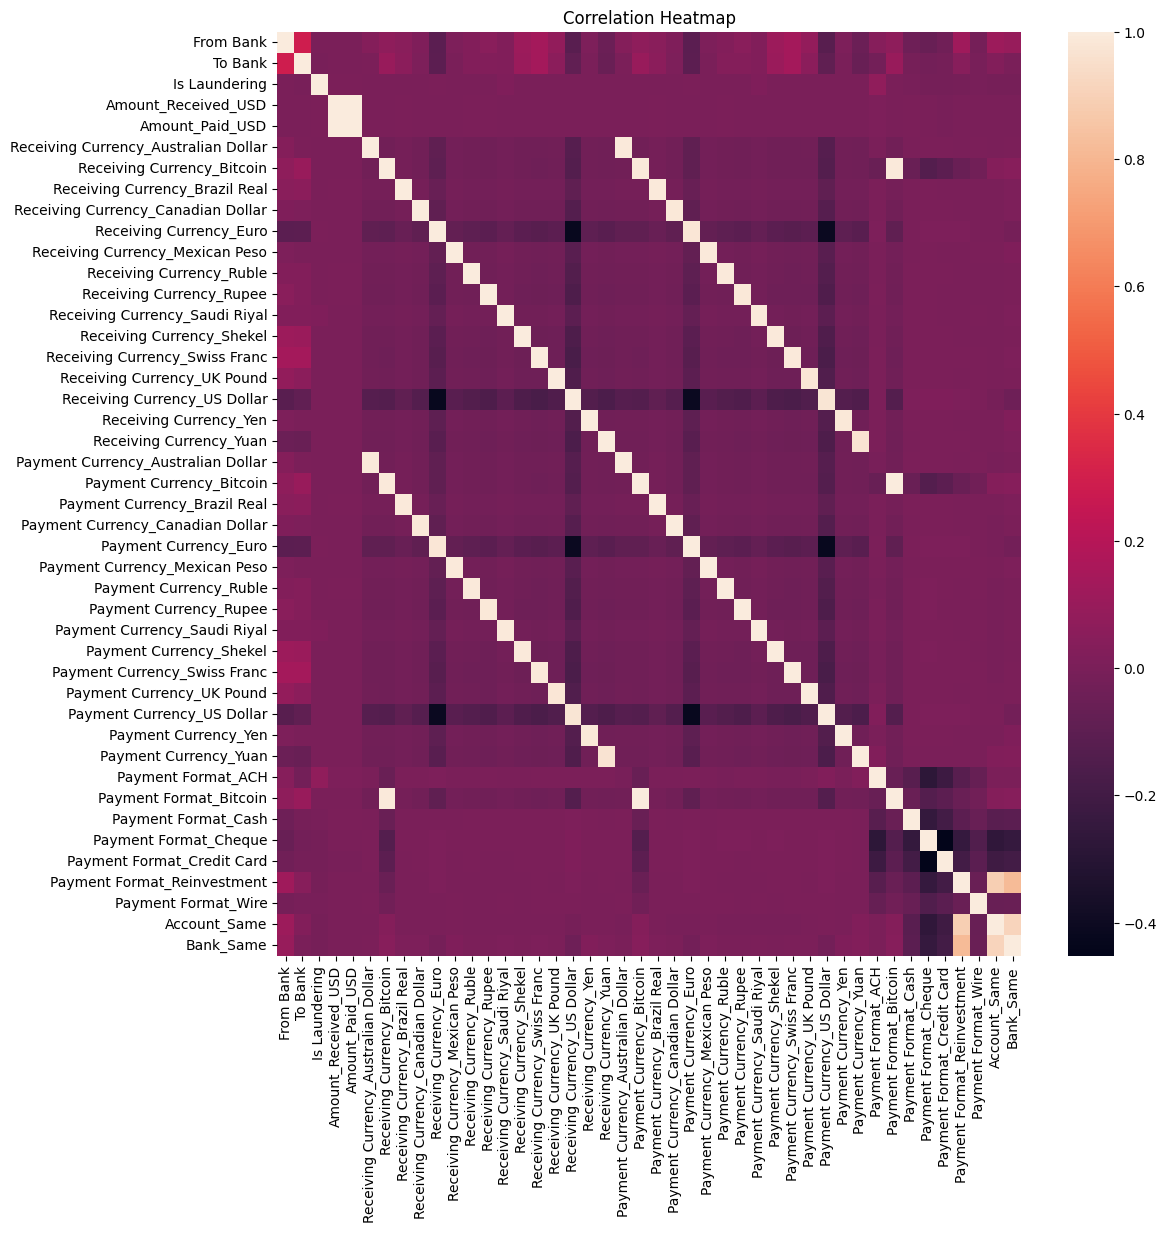

In [ ]:
plt.figure(figsize=(12, 12)) # Adjust the width and height as needed
sns.heatmap(hi_small_trans_cleaned_df.corr(numeric_only=True))
plt.title("Correlation Heatmap")
plt.savefig("ibm_figs/correlation.png", bbox_inches='tight')

In [ ]:
# plt.figure(figsize=(12, 12)) # Adjust the width and height as needed
# pd.plotting.scatter_matrix(hi_small_trans_cleaned_df, alpha=0.2)
# plt.savefig("ibm_figs/scatter_matrix.png", bbox_inches='tight')

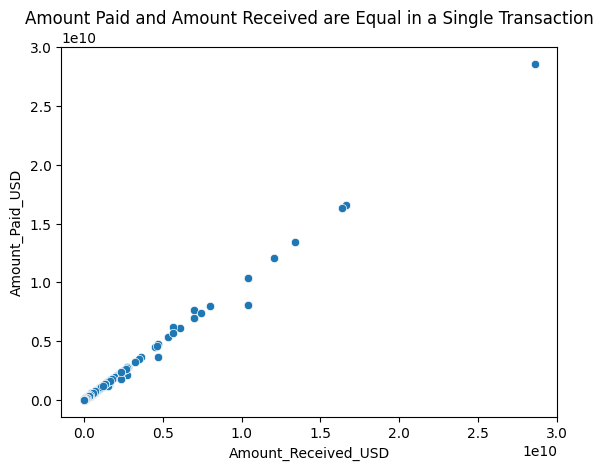

In [ ]:
# We can see that the currency conversion roughly worked. There a couple transactions that were close to perfect conversion but the rate could have been slighttly off
sns.scatterplot(x=hi_small_trans_df['Amount_Received_USD'], y=hi_small_trans_df['Amount_Paid_USD'])
plt.title("Amount Paid and Amount Received are Equal in a Single Transaction")
None

## Timeline of Transactions for a Sample Account

In [ ]:
# Plotting a timeline of transactions that contains money laundering
hi_small_trans_df[hi_small_trans_df['Is Laundering'] == 1]

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
4742,2022/09/01 00:21,70,100428660,1124,800825340,US Dollar,US Dollar,Cheque,1,3.897694e+05,3.897694e+05
40621,2022/09/01 00:03,70,100428660,11474,805B716C0,US Dollar,US Dollar,Credit Card,1,2.902433e+04,2.902433e+04
69152,2022/09/01 00:01,70,100428660,15980,80B39E7B0,US Dollar,US Dollar,Credit Card,1,7.929200e+02,7.929200e+02
85763,2022/09/01 00:03,70,100428660,113798,80DC756E0,US Dollar,US Dollar,Cheque,1,1.317143e+07,1.317143e+07
90684,2022/09/01 00:23,70,100428660,32375,80E480620,US Dollar,US Dollar,Cash,1,1.428883e+04,1.428883e+04
...,...,...,...,...,...,...,...,...,...,...,...
5071168,2022/09/10 23:29,111433,8065C2380,21550,8065C69E0,US Dollar,US Dollar,ACH,1,7.773420e+03,7.773420e+03
5073375,2022/09/10 23:07,9,80727F930,219557,8072A28C0,Ruble,Ruble,Cheque,1,7.452083e+03,7.452083e+03
5074248,2022/09/12 03:34,222,812D127D0,50202,812D129C0,Saudi Riyal,Saudi Riyal,ACH,1,5.342799e+03,5.342799e+03
5075056,2022/09/10 23:43,17327,8095F6C20,15695,8095F6C70,US Dollar,US Dollar,ACH,1,3.314360e+03,3.314360e+03


C:\Users\caleb\AppData\Local\Temp\ipykernel_28180\2168068838.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hi_transactions_sample['Timestamp_Date'] = pd.to_datetime(hi_transactions_sample['Timestamp'])


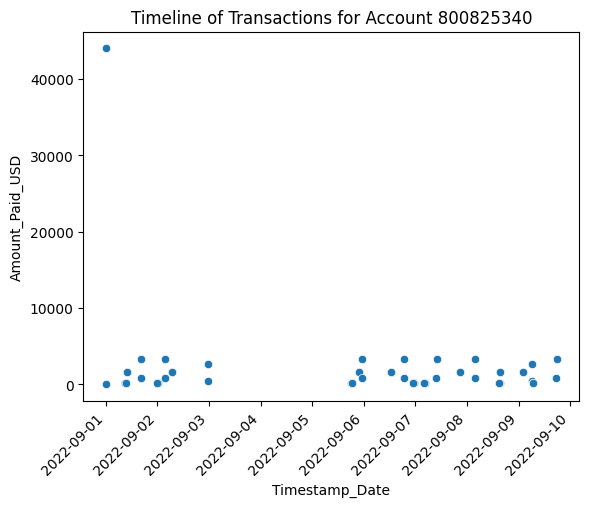

In [ ]:
hi_transactions_sample = hi_small_trans_df[hi_small_trans_df['Account'] == '800825340']
hi_transactions_sample['Timestamp_Date'] = pd.to_datetime(hi_transactions_sample['Timestamp'])
sns.scatterplot(hi_transactions_sample, x="Timestamp_Date", y="Amount_Paid_USD")
plt.xticks(rotation=45, horizontalalignment='right')
plt.title("Timeline of Transactions for Account 800825340")
None

## Bivariate Analysis

In [ ]:
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,US Dollar,US Dollar,Reinvestment,0,3697.340000,3697.340000
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,US Dollar,US Dollar,Cheque,0,0.010000,0.010000
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,US Dollar,US Dollar,Reinvestment,0,14675.570000,14675.570000
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,US Dollar,US Dollar,Reinvestment,0,2806.970000,2806.970000
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,US Dollar,US Dollar,Reinvestment,0,36682.970000,36682.970000
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,3107.386389,3107.386389
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,2168.020464,2168.020464
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,100.011894,100.011894
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,770.280058,770.280058


In [ ]:
hi_small_trans_df[hi_small_trans_df['Receiving Currency'] != hi_small_trans_df['Payment Currency']]

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
1173,2022/09/01 00:22,1362,80030A870,1362,80030A870,Euro,US Dollar,ACH,0,51.823395,61.06
7156,2022/09/01 00:28,11318,800C51010,11318,800C51010,Euro,US Dollar,ACH,0,75.641670,89.12
7925,2022/09/01 00:12,795,800D98770,795,800D98770,Australian Dollar,US Dollar,ACH,0,12.009741,12.52
8467,2022/09/01 00:01,1047,800E92CF0,1047,800E92CF0,Euro,US Dollar,ACH,0,19.323135,22.77
11529,2022/09/01 00:22,11157,80135FFC0,11157,80135FFC0,Euro,US Dollar,ACH,0,97.799130,115.24
...,...,...,...,...,...,...,...,...,...,...,...
5078167,2022/09/10 23:30,23537,803949A90,23537,803949A90,Shekel,US Dollar,ACH,0,7775.847450,7823.96
5078234,2022/09/10 23:59,16163,803638A90,16163,803638A90,Saudi Riyal,US Dollar,ACH,0,12639.652340,12667.62
5078236,2022/09/10 23:55,16163,803638A90,16163,803638A90,Saudi Riyal,US Dollar,ACH,0,3013.740100,3020.41
5078316,2022/09/10 23:44,215064,808F06E11,215064,808F06E10,Bitcoin,US Dollar,ACH,0,0.120303,0.07


In [ ]:
hi_small_trans_sample_df = hi_small_trans_df.sample(10_000)

#### Histogram of Amount Paid Colored by Payment Format

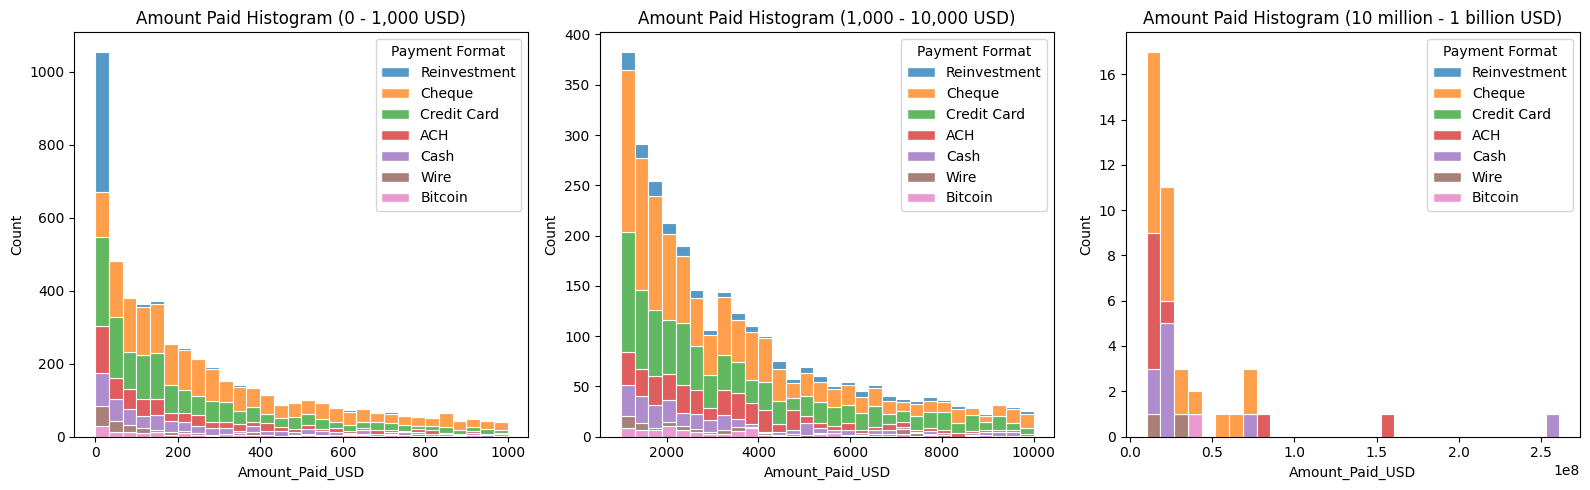

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
payment_order = hi_small_trans_df['Payment Format'].unique().tolist()
# Common parameters for readability
params = {
    "hue": "Payment Format",
    "bins": 30,
    # "palette": "viridis",  # High-contrast, colorblind-friendly palette
    "multiple": "stack",   # Prevents colors from blending in overlapping areas
    "edgecolor": "white",   # Adds definition between bars
    "hue_order": payment_order
}

sns.histplot(data=hi_small_trans_sample_df[hi_small_trans_sample_df['Amount_Paid_USD'].between(0, 1_000)], x="Amount_Paid_USD", ax=ax1, **params)
ax1.set_title("Amount Paid Histogram (0 - 1,000 USD)")
sns.histplot(data=hi_small_trans_sample_df[hi_small_trans_sample_df['Amount_Paid_USD'].between(1_000, 10_000)], x="Amount_Paid_USD", ax=ax2, **params)
ax2.set_title("Amount Paid Histogram (1,000 - 10,000 USD)")
sns.histplot(data=hi_small_trans_sample_df[hi_small_trans_sample_df['Amount_Paid_USD'].between(10_000_000, 1_000_000_000)], x="Amount_Paid_USD", ax=ax3, **params)
ax3.set_title("Amount Paid Histogram (10 million - 1 billion USD)")

plt.tight_layout()
plt.savefig("ibm_figs/amount_paid_hist.png")

#### Payment Format by Fraud

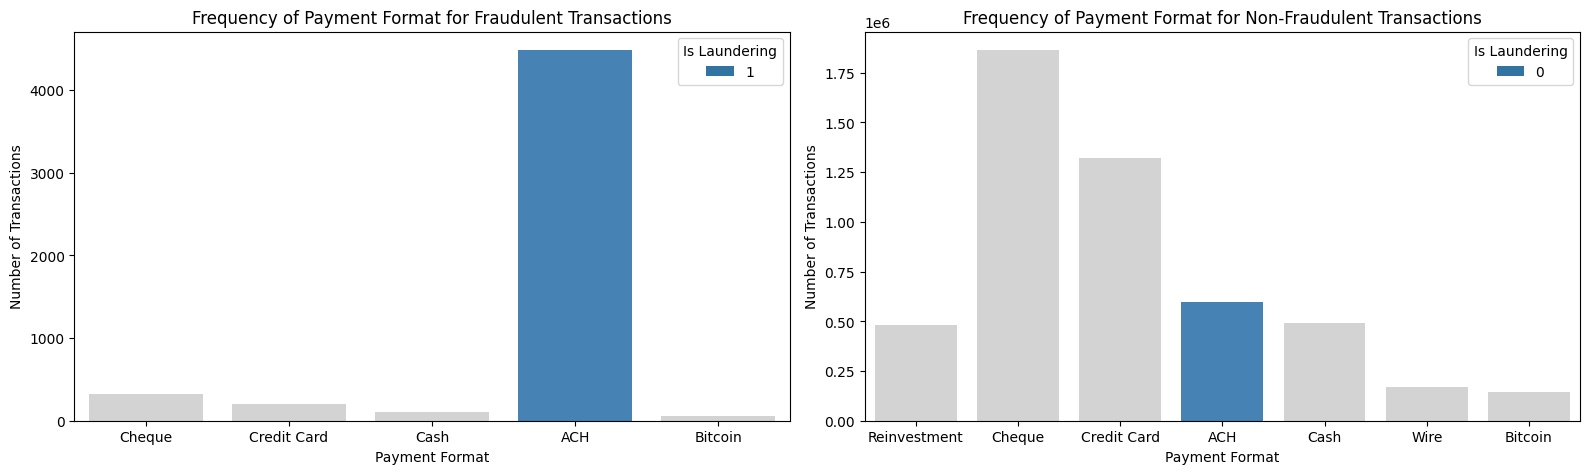

In [ ]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# sns.countplot(hi_small_trans_df[hi_small_trans_df['Is Laundering'] == 1], x='Payment Format', hue='Is Laundering', ax=ax1)
# ax1.set_title('Frequency of Payment Format for Fraudulent Transactions')
# ax1.set_xlabel('Payment Format')
# ax1.set_ylabel('Number of Transactions')

# sns.countplot(hi_small_trans_df, x='Payment Format', hue='Is Laundering', ax=ax2)
# ax2.set_title('Frequency of Payment Format for All Transactions')
# ax2.set_xlabel('Payment Format')
# ax2.set_ylabel('Number of Transactions')

# # plt.gca().get_legend().remove()
# plt.tight_layout()
# plt.savefig("ibm_figs/fraud_count_by_payment_format.png")


# 1. Define the color mapping (ACH is blue, others are lightgray)
import matplotlib.pyplot as plt
import seaborn as sns

def highlight_ach_bars(ax):
    # Get the names of the categories on the X axis
    tick_labels = [t.get_text() for t in ax.get_xticklabels()]
    
    for patch in ax.patches:
        # Calculate the center of the bar to find its corresponding tick index
        bar_center_x = patch.get_x() + patch.get_width() / 2
        tick_index = int(round(bar_center_x))
        
        # Safety check for index range
        if 0 <= tick_index < len(tick_labels):
            label = tick_labels[tick_index]
            if label == 'ACH':
                patch.set_facecolor('steelblue')
            else:
                patch.set_facecolor('lightgray')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Fraudulent Transactions (showing 0 and 1 bars side-by-side)
sns.countplot(data=hi_small_trans_df[hi_small_trans_df['Is Laundering'] == 1], 
              x='Payment Format', hue='Is Laundering', ax=ax1)
ax1.set_title('Frequency of Payment Format for Fraudulent Transactions')
ax1.set_xlabel('Payment Format')
ax1.set_ylabel('Number of Transactions')
highlight_ach_bars(ax1)

# Plot 2: All Transactions (showing 0 and 1 bars side-by-side)
sns.countplot(data=hi_small_trans_df[hi_small_trans_df['Is Laundering'] == 0], 
              x='Payment Format', hue='Is Laundering', ax=ax2)
ax2.set_title('Frequency of Payment Format for Non-Fraudulent Transactions')
ax2.set_xlabel('Payment Format')
ax2.set_ylabel('Number of Transactions')
highlight_ach_bars(ax2)

# Remove legends to keep it clean, as colors now represent the format focus
# if ax1.get_legend(): ax1.get_legend().remove()
# if ax2.get_legend(): ax2.get_legend().remove()

plt.tight_layout()
plt.savefig("ibm_figs/fraud_count_by_payment_format.png")
plt.show()


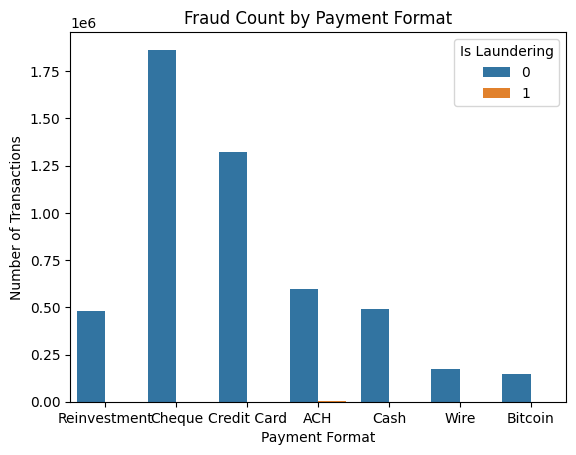

In [ ]:
sns.countplot(hi_small_trans_df, x='Payment Format', hue='Is Laundering')
plt.title('Fraud Count by Payment Format')
plt.xlabel('Payment Format')
plt.ylabel('Number of Transactions')
plt.show()

C:\Users\caleb\AppData\Local\Temp\ipykernel_28180\3352144261.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hi_small_trans_df, x='Payment Format', ax=ax1, palette=format_palette)
C:\Users\caleb\AppData\Local\Temp\ipykernel_28180\3352144261.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hi_small_trans_df, x='Payment Currency', ax=ax2, palette=currency_palette)


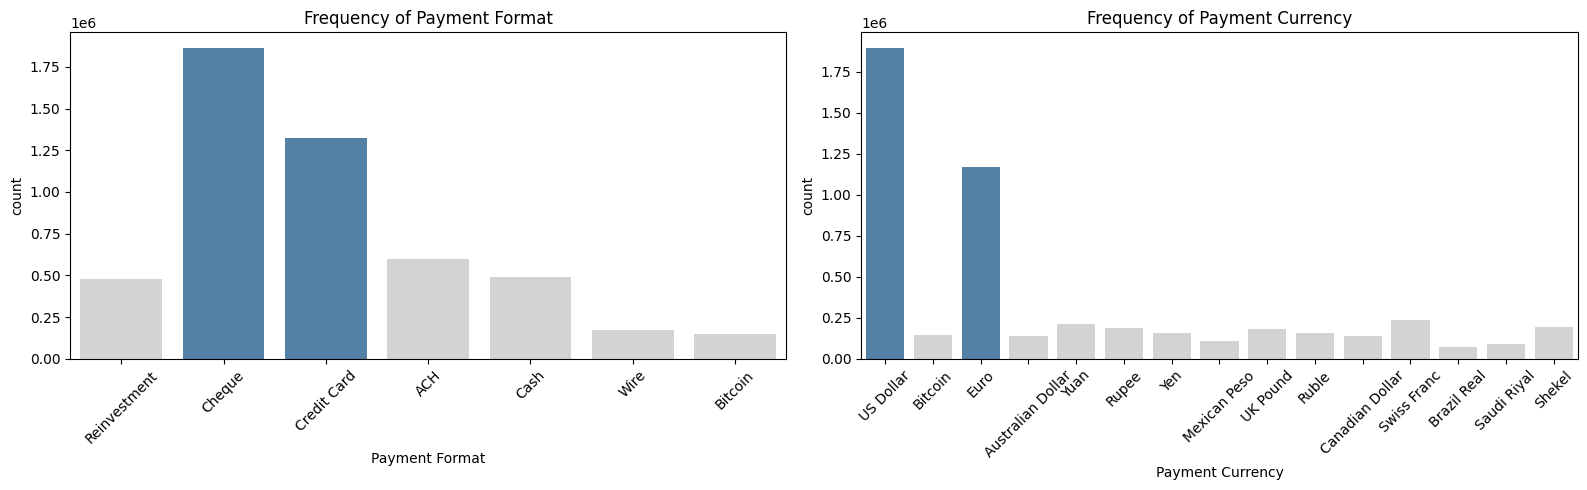

In [ ]:
# Define what you want to highlight
highlight_formats = ['Cheque', 'Credit Card'] 
highlight_currencies = ['US Dollar', 'Euro']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Plot for Payment Format
# Create a palette: highlight color vs default color
format_palette = {val: "steelblue" if val in highlight_formats else "lightgray" 
                  for val in hi_small_trans_df['Payment Format'].unique()}

sns.countplot(data=hi_small_trans_df, x='Payment Format', ax=ax1, palette=format_palette)
ax1.set_title('Frequency of Payment Format')
ax1.tick_params(axis='x', rotation=45)

# 2. Plot for Payment Currency
currency_palette = {val: "steelblue" if val in highlight_currencies else "lightgray" 
                    for val in hi_small_trans_df['Payment Currency'].unique()}

sns.countplot(data=hi_small_trans_df, x='Payment Currency', ax=ax2, palette=currency_palette)
ax2.set_title('Frequency of Payment Currency')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("ibm_figs/payment_format_and_currency.png")

In [ ]:
len(hi_small_trans_df[(hi_small_trans_df['Payment Currency'] == hi_small_trans_df['Receiving Currency']) & (hi_small_trans_df['Is Laundering'] == 1)])

5177

In [ ]:
len(hi_small_trans_df[(hi_small_trans_df['Payment Currency'] != hi_small_trans_df['Receiving Currency']) & (hi_small_trans_df['Is Laundering'] == 1)])

0

In [ ]:
hi_small_trans_df.max()

Timestamp                2022/09/18 16:18
From Bank                          356303
Account                         814965B51
To Bank                            356294
Account.1                       814965B51
Receiving Currency                   Yuan
Payment Currency                     Yuan
Payment Format                       Wire
Is Laundering                           1
Amount_Received_USD    28597983792.174046
Amount_Paid_USD        28597983792.174046
dtype: object

In [ ]:
df_pos = hi_small_trans_cleaned_df[hi_small_trans_cleaned_df['Is Laundering'] == 1]
df_neg = hi_small_trans_cleaned_df[hi_small_trans_cleaned_df['Is Laundering'] == 0]

# Sample from the majority class to reach your desired balance
# Adjust n or fraction as needed
df_neg_sample = df_neg.sample(n=len(df_pos)) 

# Combine and shuffle
balanced_df = pd.concat([df_pos, df_neg_sample]).sample(frac=1)

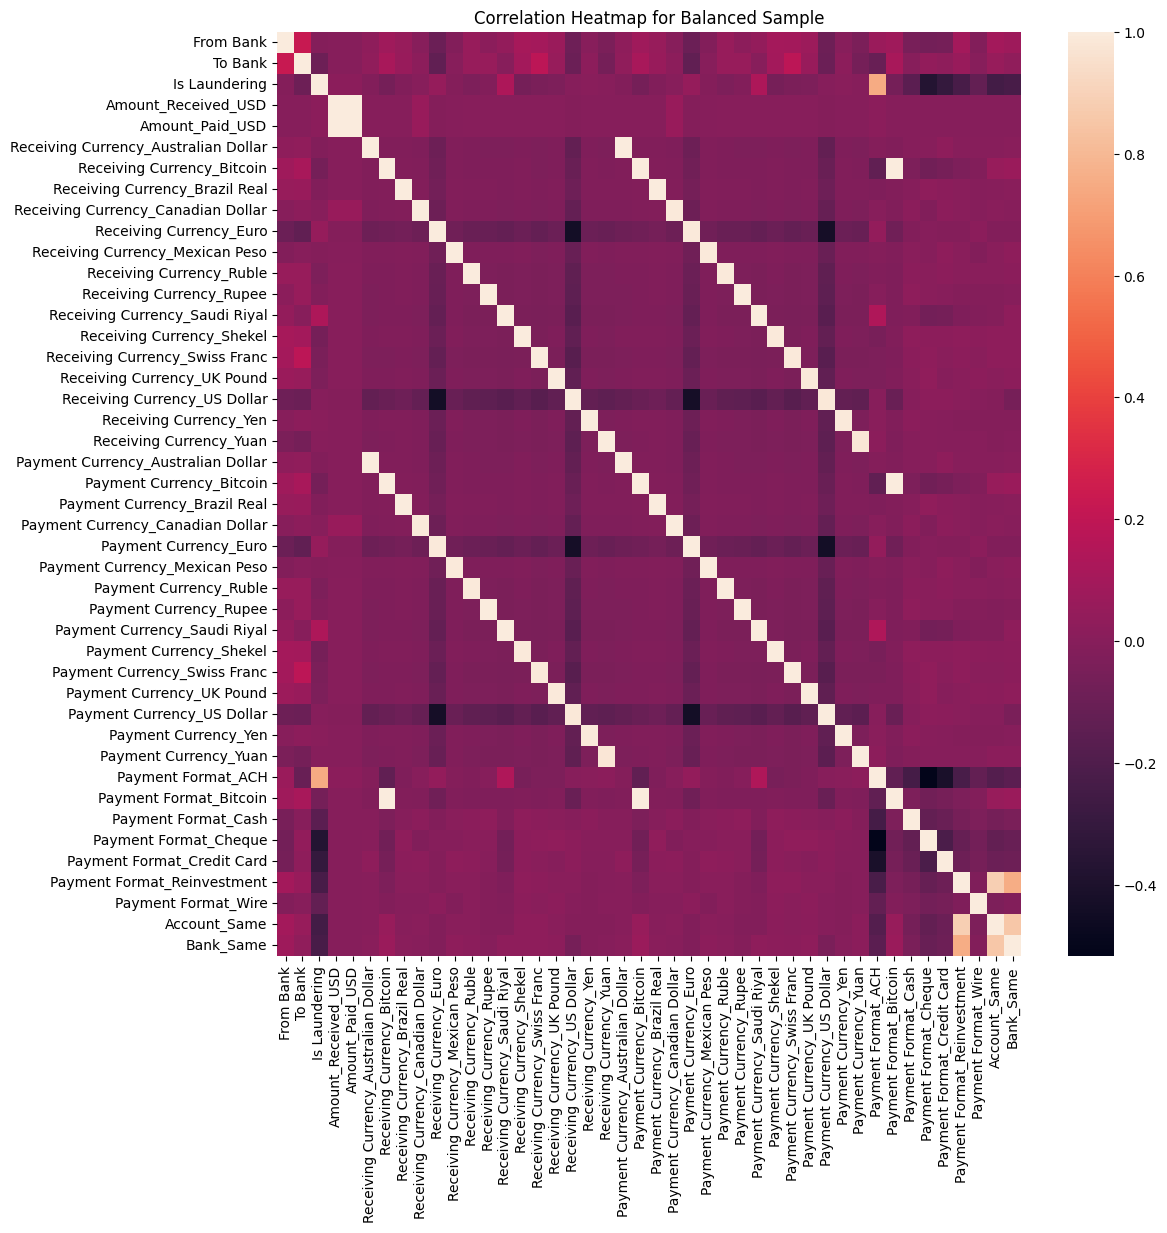

In [ ]:
plt.figure(figsize=(12, 12)) # Adjust the width and height as needed
sns.heatmap(balanced_df.corr(numeric_only=True))
plt.title("Correlation Heatmap for Balanced Sample")
plt.savefig("ibm_figs/correlation.png", bbox_inches='tight')

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
balanced_df.corr(numeric_only=True)

,From Bank,To Bank,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,Receiving Currency_Brazil Real,Receiving Currency_Canadian Dollar,Receiving Currency_Euro,Receiving Currency_Mexican Peso,Receiving Currency_Ruble,Receiving Currency_Rupee,Receiving Currency_Saudi Riyal,Receiving Currency_Shekel,Receiving Currency_Swiss Franc,Receiving Currency_UK Pound,Receiving Currency_US Dollar,Receiving Currency_Yen,Receiving Currency_Yuan,Payment Currency_Australian Dollar,Payment Currency_Bitcoin,Payment Currency_Brazil Real,Payment Currency_Canadian Dollar,Payment Currency_Euro,Payment Currency_Mexican Peso,Payment Currency_Ruble,Payment Currency_Rupee,Payment Currency_Saudi Riyal,Payment Currency_Shekel,Payment Currency_Swiss Franc,Payment Currency_UK Pound,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
From Bank,1.000000,0.227497,-0.012733,-0.001711,-0.001711,0.024417,0.083601,0.052168,0.002401,-0.097725,-0.014174,0.055687,0.016101,0.043068,0.106665,0.100015,0.068562,-0.090107,0.001183,-0.037594,0.024548,0.084701,0.052646,0.004039,-0.097135,-0.015064,0.054495,0.016832,0.042795,0.104783,0.097921,0.072205,-0.090266,0.003477,-0.038429,0.068366,0.084701,-0.053434,-0.071754,-0.062952,0.096280,-0.016969,0.094291,0.076782
To Bank,0.227497,1.000000,-0.094877,-0.006010,-0.006010,0.029318,0.113901,0.059691,0.019897,-0.136788,0.004179,0.052990,0.055531,0.003108,0.098562,0.185387,0.055530,-0.100896,0.017321,-0.062737,0.029448,0.115356,0.060319,0.021512,-0.136063,0.003451,0.052059,0.056651,0.002899,0.097094,0.184576,0.058924,-0.101438,0.019355,-0.064102,-0.109610,0.115356,0.001655,0.040003,0.025831,0.060461,-0.000901,0.053920,0.029972
Is Laundering,-0.012733,-0.094877,1.000000,0.014306,0.014306,-0.013766,-0.061752,-0.021743,0.000623,0.048331,-0.012570,-0.033688,-0.014722,0.133179,-0.062388,-0.044009,-0.031762,-0.001800,0.008114,-0.000521,-0.013766,-0.060646,-0.020980,0.000623,0.049488,-0.011900,-0.032174,-0.013198,0.134390,-0.059991,-0.040664,-0.033283,-0.004397,0.006932,-0.006669,0.747629,-0.060646,-0.156699,-0.372901,-0.307494,-0.227144,-0.131119,-0.248516,-0.229336
Amount_Received_USD,-0.001711,-0.006010,0.014306,1.000000,1.000000,-0.002333,-0.002274,-0.001941,0.063195,-0.007667,-0.002279,0.001757,0.002497,-0.001329,-0.000781,0.004418,-0.001096,-0.011048,-0.002869,-0.003024,-0.002333,-0.002261,-0.001933,0.063192,-0.007652,-0.002273,0.001793,0.002533,-0.001316,-0.000738,0.004516,-0.001119,-0.011083,-0.002882,-0.003081,0.015108,-0.002261,-0.003840,-0.006835,-0.007084,-0.003455,-0.002068,-0.003957,-0.004695
Amount_Paid_USD,-0.001711,-0.006010,0.014306,1.000000,1.000000,-0.002333,-0.002274,-0.001941,0.063195,-0.007667,-0.002279,0.001757,0.002497,-0.001329,-0.000781,0.004418,-0.001096,-0.011048,-0.002869,-0.003024,-0.002333,-0.002261,-0.001933,0.063192,-0.007652,-0.002273,0.001793,0.002533,-0.001316,-0.000738,0.004516,-0.001119,-0.011083,-0.002882,-0.003081,0.015108,-0.002261,-0.003840,-0.006835,-0.007084,-0.003455,-0.002068,-0.003956,-0.004694
Receiving Currency_Australian Dollar,0.024417,0.029318,-0.013766,-0.002333,-0.002333,1.000000,-0.023269,-0.019411,-0.026345,-0.094255,-0.023387,-0.029941,-0.031557,-0.035871,-0.028541,-0.036635,-0.029656,-0.127112,-0.028442,-0.031872,0.996291,-0.023150,-0.019340,-0.026345,-0.094132,-0.023328,-0.029799,-0.031422,-0.035790,-0.028294,-0.036315,-0.029799,-0.126216,-0.028541,-0.032406,-0.011174,-0.023150,-0.002227,0.000223,0.024535,0.001135,0.001478,-0.000501,0.008534
Receiving Currency_Bitcoin,0.083601,0.113901,-0.061752,-0.002274,-0.002274,-0.023269,1.000000,-0.016431,-0.022301,-0.079786,-0.019797,-0.025345,-0.026713,-0.030365,-0.024160,-0.031011,-0.025103,-0.107599,-0.024076,-0.026980,-0.023269,0.994889,-0.016371,-0.022301,-0.078048,-0.019747,-0

## Conclusions

The IBM synthetic accounts/transactions dataset is high quality. There are no missing values to handle. There are some duplicates instances, but none that we need to drop. Additionally, there are a large number of instances we can use for analysis.

In the boxplots, we can see some outliers for the Amount Recieved/Paid features. The outliers are for large amounts. The majority of transactions are for small sums

The Amount Received/Paid features are highly correlated. This is because they are equal and opposite to each other. Having the duplicate information will be useful for building the full relationship of transactions for a given account

Looking at a sample account which had fraudulent transaction, we see a number of smaller transactions and single large transaction. One strategy that a fraudster might utilize is spending a large sum from an account they have taken over. This does not cover all possible methods though. More in depth analysis will be needed to uncover these patterns.

The largest challenge with this dataset is that feature engineering is required before analysis. There is only a small number of features. The real insights into fraud will come from building up a full picture of the transactions for each account. From here the model can learn what types of transactions are dissimilar to normal ones. One strategy I will employ is creating an engineered feature to represent the average purchase amount for an account, as well as the amount of times two accounts have sent money to each other.

In [ ]:
hi_small_trans_cleaned_df.to_csv('ibm_hi_small_trans_cleaned.csv', index=False)

In [ ]:
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0,3697.340000,3697.340000
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0,0.010000,0.010000
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0,14675.570000,14675.570000
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0,2806.970000,2806.970000
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0,36682.970000,36682.970000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0,3107.386389,3107.386389
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0,2168.020464,2168.020464
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0,100.011894,100.011894
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0,770.280058,770.280058


## Extra stuff for Milestone 4

In [24]:
fraud = hi_small_trans_df[hi_small_trans_df['Is Laundering'] == 1]
non_fraud = hi_small_trans_df[hi_small_trans_df['Is Laundering'] == 0]
len(fraud), len(non_fraud)

(5177, 5073168)

In [25]:
# Undersample majority class to a 1:10 ratio
non_fraud_downsampled = non_fraud.sample(n=len(fraud) * 10, random_state=42)
non_fraud_downsampled

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
4563287,2022/09/09 12:02,348286,811C389E0,148016,811C53230,1439.79,Saudi Riyal,1439.79,Saudi Riyal,Credit Card,0,3.829841e+02,3.829841e+02
4216770,2022/09/09 00:18,22345,801B0C870,215266,80FA67C30,33.09,US Dollar,33.09,US Dollar,Credit Card,0,3.309000e+01,3.309000e+01
2992877,2022/09/06 10:33,1267,800E00D50,14,801ED33F0,263.34,Yuan,263.34,Yuan,ACH,0,3.807896e+01,3.807896e+01
1499016,2022/09/02 11:32,138395,80E8DB8D0,238190,80F684920,17154983.76,Swiss Franc,17154983.76,Swiss Franc,Cheque,0,1.747064e+07,1.747064e+07
510282,2022/09/01 05:49,43049,80FF89190,217,8101478B0,8499.22,Shekel,8499.22,Shekel,Cheque,0,2.501320e+03,2.501320e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3992741,2022/09/08 12:34,1241,800A92500,17729,80AE99C60,5722.87,US Dollar,5722.87,US Dollar,Cheque,0,5.722870e+03,5.722870e+03
44465,2022/09/01 00:29,11318,803530C10,908,8066BE4D0,82208.92,US Dollar,82208.92,US Dollar,Cash,0,8.220892e+04,8.220892e+04
1173046,2022/09/02 01:19,213,809101240,19,8092ED8C0,6837.09,Canadian Dollar,6837.09,Canadian Dollar,Credit Card,0,5.196872e+03,5.196872e+03
4125810,2022/09/08 19:26,220541,8082AB410,222697,808A9F3F0,3261.27,UK Pound,3261.27,UK Pound,Wire,0,3.763506e+03,3.763506e+03


In [26]:
# Combine and shuffle
df_reduced = pd.concat([fraud, non_fraud_downsampled]).sample(frac=1).reset_index(drop=True)
df_reduced

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/07 19:41,215266,8075AFB00,1,80B3E93A0,9702.45,US Dollar,9702.45,US Dollar,Credit Card,0,9.702450e+03,9.702450e+03
1,2022/09/02 00:25,1362,803796BB0,227143,80D43FD30,33.55,US Dollar,33.55,US Dollar,Credit Card,0,3.355000e+01,3.355000e+01
2,2022/09/09 09:58,320509,808C13640,121580,808C135F0,362.37,UK Pound,362.37,UK Pound,Credit Card,0,4.181750e+02,4.181750e+02
3,2022/09/01 00:23,128727,80AE4E640,128727,80AE4E640,1824292.50,Australian Dollar,1824292.50,Australian Dollar,Reinvestment,0,1.238512e+06,1.238512e+06
4,2022/09/01 09:57,132306,812840CE0,132306,812840CE0,10459.75,US Dollar,10459.75,US Dollar,Reinvestment,0,1.045975e+04,1.045975e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56942,2022/09/07 04:37,14,80FD46D70,243947,810043070,2746.19,Shekel,2746.19,Shekel,Credit Card,0,8.082037e+02,8.082037e+02
56943,2022/09/02 08:36,131800,80E385380,123308,80E385330,1984.13,Euro,1984.13,Euro,ACH,0,1.973217e+03,1.973217e+03
56944,2022/09/07 17:33,239453,80E8941E0,40653,80F6B3000,4436.35,Swiss Franc,4436.35,Swiss Franc,Credit Card,0,4.517979e+03,4.517979e+03
56945,2022/09/09 09:47,13858,80E4234E0,27140,812761240,4907.82,Euro,4907.82,Euro,Credit Card,0,4.880827e+03,4.880827e+03


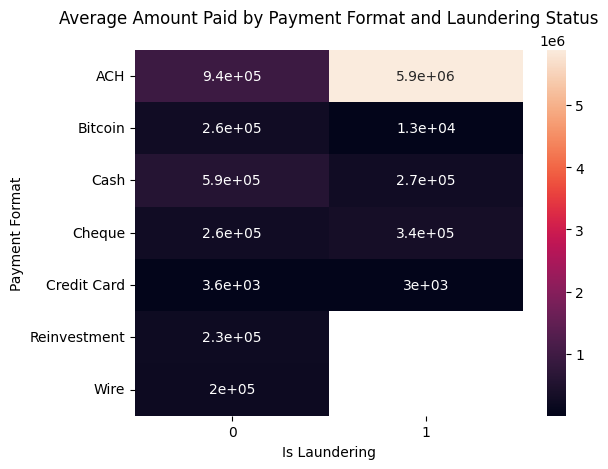

In [27]:
pivot2 = df_reduced.pivot_table(index = ['Payment Format'], columns = ["Is Laundering"], values = "Amount_Paid_USD", aggfunc = "mean") # note mean, not sum this time
ax2 = sns.heatmap(pivot2, annot=True)
plt.title("Average Amount Paid by Payment Format and Laundering Status", y=1.05)
plt.tight_layout()

plt.savefig("../Milestone 4 EDA/ibm_figs/heatmap.png", bbox_inches='tight')

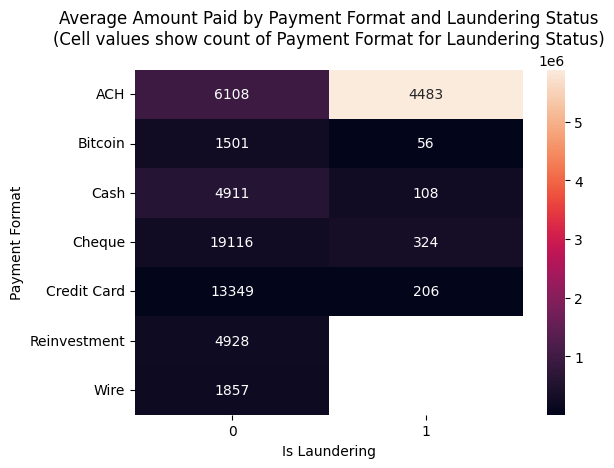

In [32]:
import numpy as np

# 1. Calculate the mean (for the colors)
pivot2 = df_reduced.pivot_table(index=['Payment Format'], 
                               columns=["Is Laundering"], 
                               values="Amount_Paid_USD", 
                               aggfunc="mean")

# 2. Calculate the count (for the labels)
pivot_counts = df_reduced.pivot_table(index=['Payment Format'], 
                                     columns=["Is Laundering"], 
                                     values="Amount_Paid_USD", 
                                     aggfunc="count").fillna(0).astype(int)

# 3. Create the heatmap
# We use pivot2 for the data/colors, and pivot_counts for the annotation
ax2 = sns.heatmap(pivot2, annot=pivot_counts, fmt='d')

plt.title("Average Amount Paid by Payment Format and Laundering Status\n(Cell values show count of Payment Format for Laundering Status)", y=1.05)
plt.tight_layout()

plt.savefig("../Milestone 4 EDA/ibm_figs/heatmap.png", bbox_inches='tight')


In [28]:
pivot2

Is Laundering,0,1
Payment Format,,
ACH,941396.012879,5.890081e+06
Bitcoin,261835.592281,1.253913e+04
Cash,594987.950516,2.665739e+05
Cheque,258592.116013,3.367123e+05
Credit Card,3574.473864,2.990576e+03
Reinvestment,232471.968929,NaN
Wire,200407.689969,NaN
